# Camada Gold - Crianças, municípios, estratégias e qualidade do registro

Continuação de [06-gold-panorama-vacinacao.ipynb](06-gold-panorama-vacinacao.ipynb), com as tabelas gold mais analíticas:

- **Coorte de crianças de 1-4 anos** por município (quantas receberam 1 e 2+ doses).
- **Estabelecimentos e estratégias** de vacinação.
- **Atraso** entre aplicar a dose e o registro chegar ao RNDS.

## 1. Setup

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Paleta categorica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE = "#2a78d6"
TEXT_PRIMARY, TEXT_SECONDARY, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY, "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.options.display.float_format = "{:,.2f}".format

PROCESSED = Path("..") / "data" / "vacinacao" / "processed"
SILVER = PROCESSED / "silver" / "vacinacao_sarampo_sipni.parquet"
GOLD = PROCESSED / "gold"


def milhar(ax, eixo="y"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
    (ax.yaxis if eixo == "y" else ax.xaxis).set_major_formatter(fmt)


def titulo(ax, texto):
    ax.set_title(texto, loc="left", fontweight="bold")

coorte = pd.read_parquet(GOLD / "gold_coorte_criancas_municipio.parquet")
mun_mes = pd.read_parquet(GOLD / "gold_municipio_mes.parquet")
estab = pd.read_parquet(GOLD / "gold_estabelecimento.parquet")
atraso = pd.read_parquet(GOLD / "gold_atraso_registro.parquet")
print({n: len(t) for n, t in [("coorte", coorte), ("municipio_mes", mun_mes), ("estabelecimento", estab), ("atraso", atraso)]})

{'coorte': 5574, 'municipio_mes': 99989, 'estabelecimento': 18714, 'atraso': 2522}


## 2. Crianças de 1 a 4 anos: quem completou o esquema?
`criancas_vacinadas` = crianças distintas de 1-4 anos com ao menos uma dose na janela; `com_2_ou_mais` = com doses em ao menos duas datas diferentes. **Não é cobertura vacinal**: o denominador é quem já foi vacinado, não a população de crianças. Mede o quanto quem entrou no esquema **retornou** para a 2ª dose.

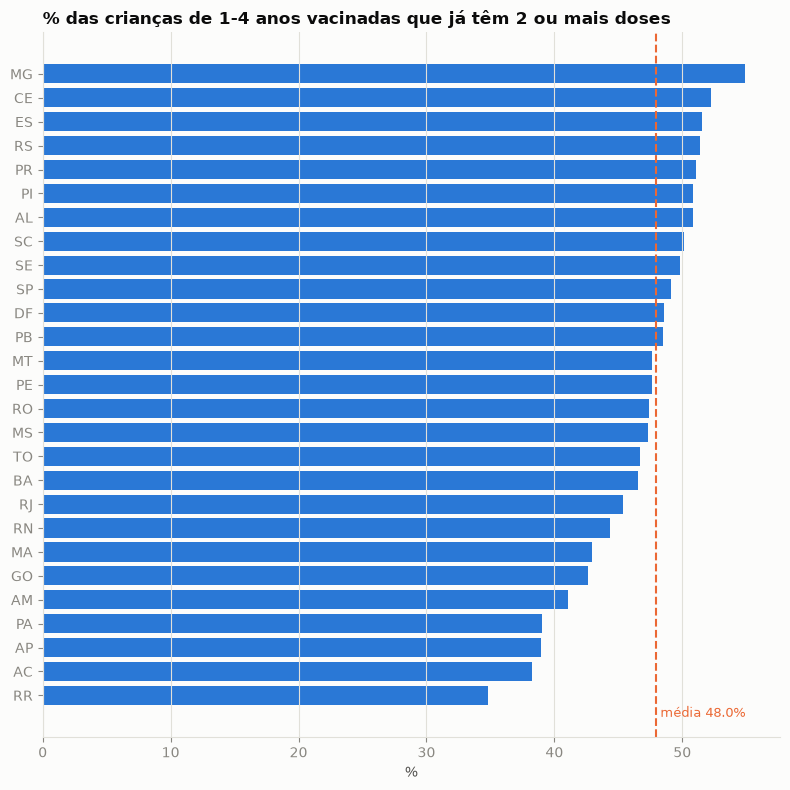

In [2]:
uf = coorte.groupby("uf_paciente")[["criancas_vacinadas", "criancas_com_2_ou_mais_doses"]].sum()
uf["prop"] = uf["criancas_com_2_ou_mais_doses"] / uf["criancas_vacinadas"] * 100
uf = uf[uf["criancas_vacinadas"] > 1000].sort_values("prop")
media = uf["criancas_com_2_ou_mais_doses"].sum() / uf["criancas_vacinadas"].sum() * 100
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(uf.index.astype(str), uf["prop"], color=BLUE)
ax.axvline(media, color=CATEGORICAL[1], linestyle="--", linewidth=1.5)
ax.text(media, -0.9, f" média {media:.1f}%", color=CATEGORICAL[1], fontsize=9)
titulo(ax, "% das crianças de 1-4 anos vacinadas que já têm 2 ou mais doses")
ax.set_xlabel("%"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### Distribuição entre municípios (mín. 100 crianças vacinadas)

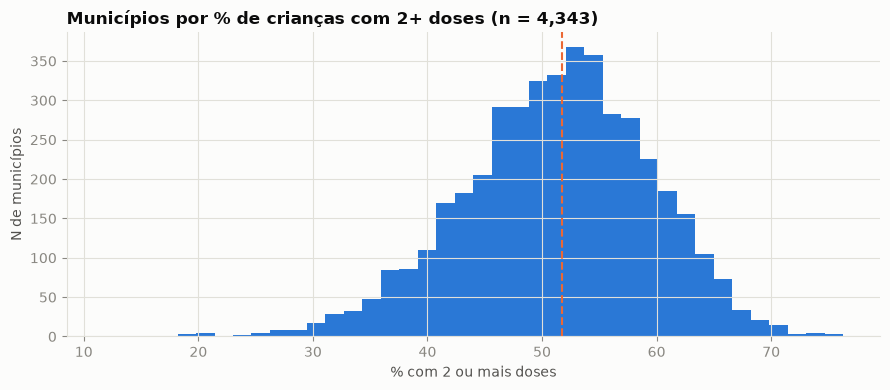

Menores proporções:


,municipio,uf_paciente,criancas_vacinadas,prop_com_2_ou_mais
5572,INVALIDO,<NA>,162,0.12
4239,PIRATINI,RS,166,0.17
2489,MELGACO,PA,764,0.19
1170,CACHOEIRA GRANDE,MA,323,0.20
1333,TUFILANDIA,MA,148,0.20
3915,PACARAIMA,RR,6171,0.21
3099,MILTON BRANDAO,PI,152,0.21
2526,SANTA CRUZ DO ARARI,PA,127,0.21
2461,CURRALINHO,PA,927,0.21
1172,CAJARI,MA,365,0.24


Maiores proporções:


,municipio,uf_paciente,criancas_vacinadas,prop_com_2_ou_mais
4110,HARMONIA,RS,118,0.76
1652,GAMELEIRAS,MG,104,0.75
2097,SAO ROMAO,MG,158,0.75
1568,CRISTALIA,MG,111,0.74
3452,PAULA FREITAS,PR,145,0.74
4694,TUNAPOLIS,SC,122,0.74
1370,ALVORADA DE MINAS,MG,113,0.73
3591,VIRMOND,PR,104,0.73
4350,SERTAO SANTANA,RS,118,0.73
4420,AGRONOMICA,SC,172,0.73


In [3]:
c = coorte[coorte["criancas_vacinadas"] >= 100].copy()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(c["prop_com_2_ou_mais"] * 100, bins=40, color=BLUE)
ax.axvline(c["prop_com_2_ou_mais"].median() * 100, color=CATEGORICAL[1], linestyle="--")
titulo(ax, f"Municípios por % de crianças com 2+ doses (n = {len(c):,})")
ax.set_xlabel("% com 2 ou mais doses"); ax.set_ylabel("N de municípios")
plt.tight_layout(); plt.show()

cols = ["municipio", "uf_paciente", "criancas_vacinadas", "prop_com_2_ou_mais"]
print("Menores proporções:"); display(c.nsmallest(10, "prop_com_2_ou_mais")[cols])
print("Maiores proporções:"); display(c.nlargest(10, "prop_com_2_ou_mais")[cols])

## 3. Municípios com mais doses

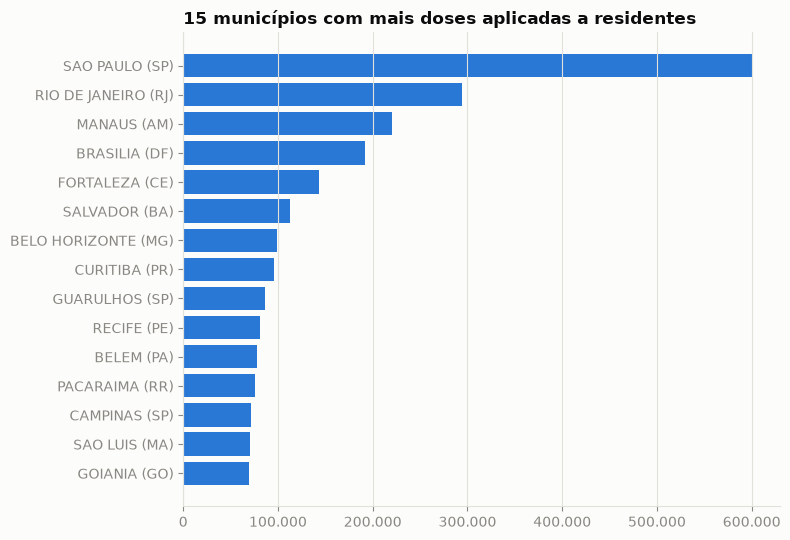

In [4]:
top = mun_mes.groupby(["codigo_municipio_paciente", "municipio", "uf"], as_index=False)["doses"].sum().nlargest(15, "doses").iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["municipio"] + " (" + top["uf"] + ")", top["doses"], color=BLUE)
titulo(ax, "15 municípios com mais doses aplicadas a residentes")
milhar(ax, "x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 4. Estratégia e tipo de estabelecimento

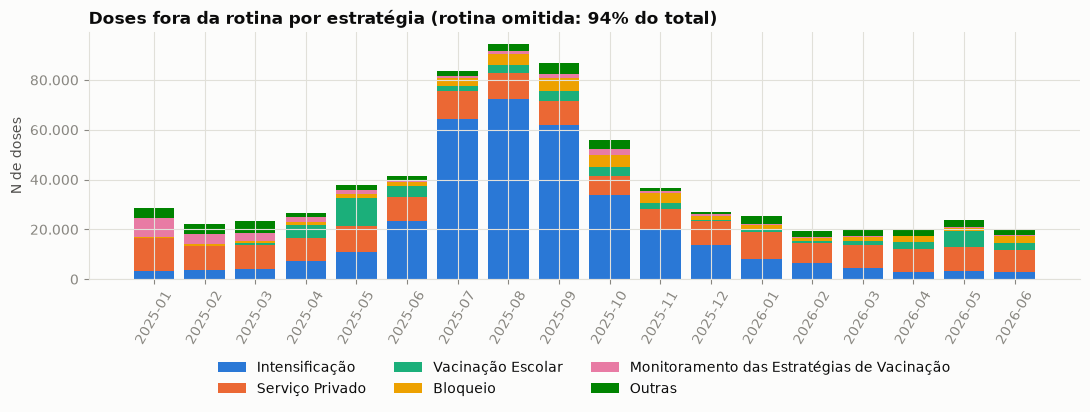

In [5]:
e = estab.pivot_table(index="ano_mes", columns="estrategia_vacinacao", values="doses", aggfunc="sum").fillna(0)
share_rotina = e["Rotina"].sum() / e.sum().sum() * 100
principais = e.drop(columns="Rotina").sum().nlargest(5).index
fora = e[principais].copy(); fora["Outras"] = e.drop(columns=list(principais) + ["Rotina"]).sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 4.5))
base = np.zeros(len(fora))
for cor, col in zip(CATEGORICAL, fora.columns):
    ax.bar(fora.index, fora[col], bottom=base, label=col, color=cor); base += fora[col].values
titulo(ax, f"Doses fora da rotina por estratégia (rotina omitida: {share_rotina:.0f}% do total)")
ax.set_ylabel("N de doses"); milhar(ax); ax.tick_params(axis="x", rotation=60)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.28))
plt.tight_layout(); plt.show()

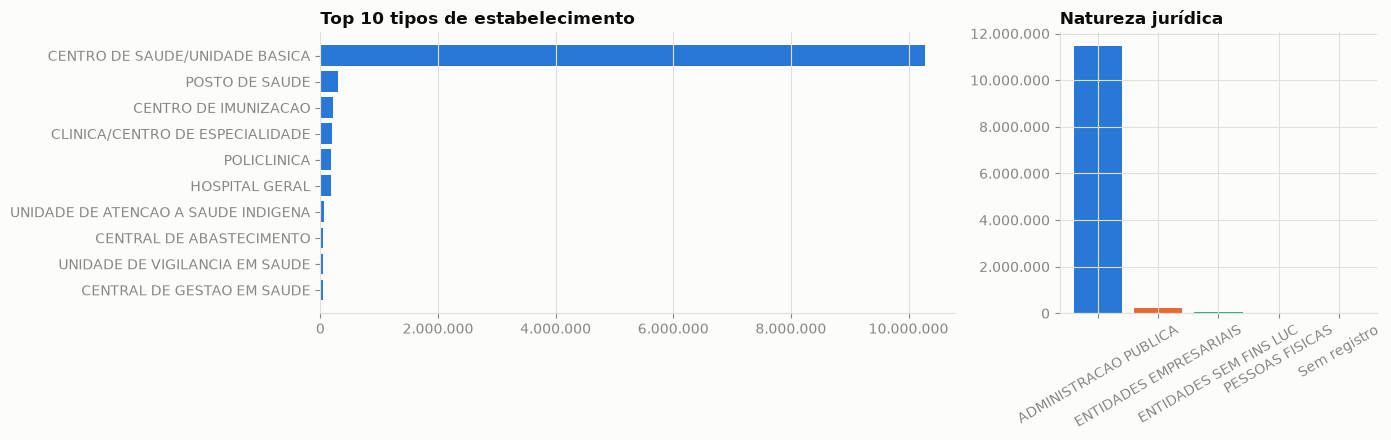

In [6]:
sem = "Sem registro"
tipo = estab.fillna({"tipo_estabelecimento": sem}).groupby("tipo_estabelecimento")["doses"].sum().nlargest(10).iloc[::-1]
nat = estab.fillna({"natureza_estabelecimento": sem}).groupby("natureza_estabelecimento")["doses"].sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [2, 1]})
axes[0].barh(tipo.index.str.slice(0, 45), tipo.values, color=BLUE); titulo(axes[0], "Top 10 tipos de estabelecimento"); milhar(axes[0], "x"); axes[0].grid(axis="y", visible=False)
axes[1].bar(nat.index.str.slice(0, 22), nat.values, color=CATEGORICAL[: len(nat)]); titulo(axes[1], "Natureza jurídica"); milhar(axes[1]); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 5. Atraso no registro (qualidade do dado)
Diferença entre a data da dose e a data em que o registro entrou no RNDS. Atraso alto significa que os números **mais recentes ficam subestimados** até os registros chegarem; cuidado ao interpretar os últimos meses.

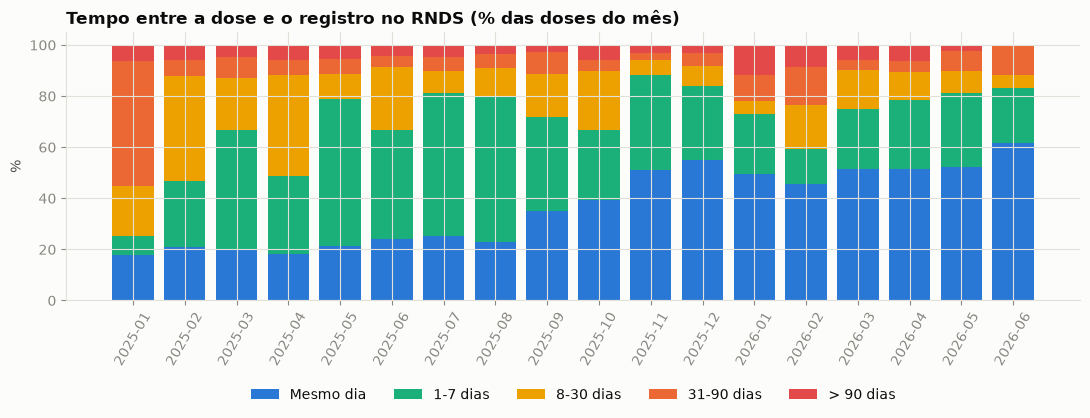

In [7]:
ordem = ["Mesmo dia", "1-7 dias", "8-30 dias", "31-90 dias", "> 90 dias"]
a = atraso.pivot_table(index="ano_mes", columns="faixa_atraso", values="doses", aggfunc="sum").reindex(columns=ordem).fillna(0)
a = a.div(a.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
base = np.zeros(len(a))
for cor, col in zip(["#2a78d6", "#1baf7a", "#eda100", "#eb6834", "#e34948"], a.columns):
    ax.bar(a.index, a[col], bottom=base, label=col, color=cor); base += a[col].values
titulo(ax, "Tempo entre a dose e o registro no RNDS (% das doses do mês)")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=60)
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.28))
plt.tight_layout(); plt.show()

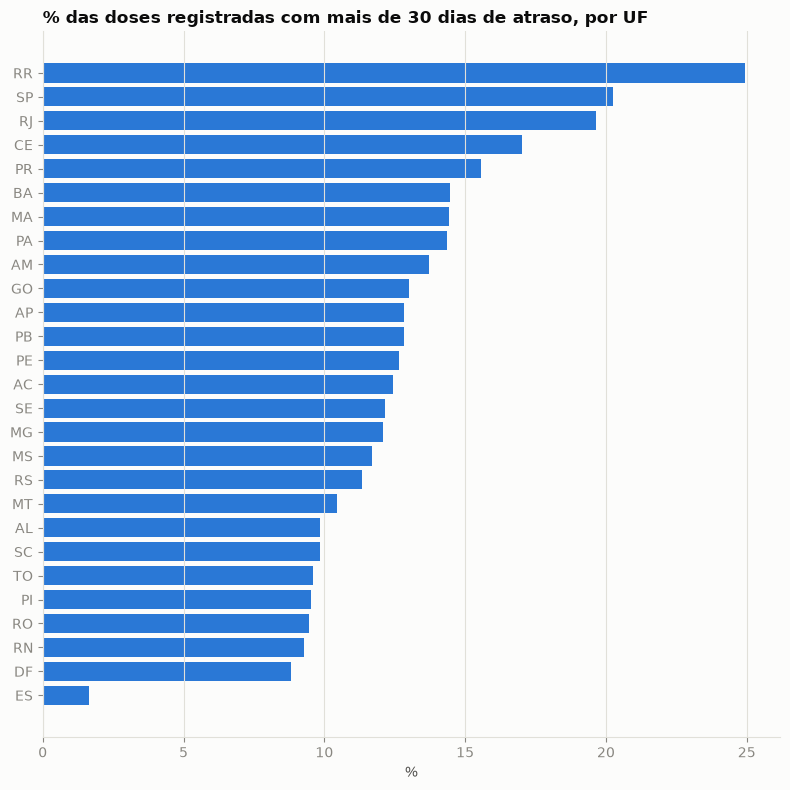

In [8]:
por_uf = atraso.pivot_table(index="uf_paciente", columns="faixa_atraso", values="doses", aggfunc="sum").fillna(0)
por_uf["total"] = por_uf.sum(axis=1)
por_uf = por_uf[por_uf["total"] > 5000]
s = ((por_uf["31-90 dias"] + por_uf["> 90 dias"]) / por_uf["total"] * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(s.index.astype(str), s.values, color=BLUE)
titulo(ax, "% das doses registradas com mais de 30 dias de atraso, por UF")
ax.set_xlabel("%"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## Leituras
- A proporção de crianças de 1-4 anos com 2+ doses varia entre UFs e municípios: candidata a mapa e a priorização de busca ativa.
- Municípios com poucas crianças produzem proporções instáveis (por isso o corte mínimo de 100).
- O atraso de registro é heterogêneo entre UFs e caiu ao longo de 2025, o que também afeta quão "completo" está o mês mais recente.